# Daily Cross-Sectional Spread Decomposition

Decompose each bond's G-Spread into systematic factors (sector, rating, duration) via daily cross-sectional OLS, then track factor betas over time and use residuals as mean-reversion signals.

**Model (for each trading day t):**
$$\text{Spread}_{i,t} = \beta_{0,t} + \sum_k \beta^{\text{sector}}_{k,t}\,\mathbf{1}[s_i{=}k] + \sum_r \beta^{\text{rating}}_{r,t}\,\mathbf{1}[r_i{=}r] + \beta^{\text{dur}}_t\,D_i + \beta^{\text{dur2}}_t\,D_i^2 + \varepsilon_{i,t}$$

Robust SEs: HC3. Residuals are standardized per day → AR(1) per bond → mean-reversion half-life.

## 1. Imports & config

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = Path('../Agg_Data.xlsx')
OUT_DIR = Path('.')
OUT_DIR.mkdir(exist_ok=True)

MIN_BONDS_PER_BUCKET = 3
RATING_REFERENCE = 'A'       # most populated tier typically
SECTOR_REFERENCE = None      # set after inspection; None = let pandas pick first alphabetically

## 2. Load data

Two sheets: `Agg_Dirty_Spread` (wide: dates × CUSIP) and `Agg_Fixed_Field` (CUSIP × metadata).

In [35]:
spread_wide = pd.read_excel(DATA_PATH, sheet_name='Agg_Dirty_Spread', index_col=0)
fixed = pd.read_excel(DATA_PATH, sheet_name='Agg_Fixed_Field', index_col=0)

spread_wide.index = pd.to_datetime(spread_wide.index)
print('Spread panel:', spread_wide.shape, '| dates:', spread_wide.index.min().date(), '→', spread_wide.index.max().date())
print('Fixed fields:', fixed.shape)
fixed.head()

Spread panel: (499, 303) | dates: 2024-03-01 → 2026-02-26
Fixed fields: (303, 10)


,Amt Out,Cpn,Maturity,BBG Composite,Mac Dur (Ask),ISSUER,CPN_FREQ,RTG_MOODY,BICS_LEVEL_1_SECTOR_NAME,BICS_LEVEL_2_INDUSTRY_GROUP_NAME
CUSIP,,,,,,,,,,
0010EPAF5,275000000,6.65,2/15/2033,BBB,5.726529,AEP TEXAS INC,2,Baa3,Utilities,Utilities
00138EAY0,700000000,5.35,6/24/2026,A,0.300000,COREBRIDGE GLOB FUNDING,2,A2,Financials,Life Insurance
00138EBB9,1000000000,4.65,8/20/2027,A,1.421858,COREBRIDGE GLOB FUNDING,2,A2,Financials,Life Insurance
00182FBJ4,500000000,3.45,1/21/2028,A+,1.824424,ANZ NEW ZEALAND INTL/LDN,2,A1,Financials,Banks
00182FBM7,750000000,2.55,2/13/2030,A+,3.758013,ANZ NEW ZEALAND INTL/LDN,2,A1,Financials,Banks


In [36]:
# Inspect the metadata columns so we know what to map
print(fixed.columns.tolist())

['Amt Out', 'Cpn', 'Maturity', 'BBG Composite', 'Mac Dur (Ask)', 'ISSUER', 'CPN_FREQ', 'RTG_MOODY', 'BICS_LEVEL_1_SECTOR_NAME', 'BICS_LEVEL_2_INDUSTRY_GROUP_NAME']


## 3. Build long panel and feature columns

In [37]:
# --- Adjust these column names if the actual headers differ ---
COL_SECTOR = 'BICS_LEVEL_1_SECTOR_NAME'
COL_RATING_RAW = 'BBG Composite'
COL_DURATION = 'Mac Dur (Ask)'

# Collapse +/- modifiers -> broad tier
def broad_rating(r):
    if pd.isna(r):
        return np.nan
    r = str(r).strip().upper()
    for t in ['AAA', 'AA', 'BBB', 'BB', 'A', 'B']:
        if r.startswith(t):
            return t
    return np.nan

meta = fixed[[COL_SECTOR, COL_RATING_RAW, COL_DURATION]].copy()
meta.columns = ['sector', 'rating_raw', 'duration']
meta['rating'] = meta['rating_raw'].apply(broad_rating)
meta = meta[['sector', 'rating', 'duration']].dropna()
print('Bonds with complete metadata:', len(meta))
meta.head()

Bonds with complete metadata: 303


,sector,rating,duration
CUSIP,,,
0010EPAF5,Utilities,BBB,5.726529
00138EAY0,Financials,A,0.300000
00138EBB9,Financials,A,1.421858
00182FBJ4,Financials,A,1.824424
00182FBM7,Financials,A,3.758013


In [38]:
# Long panel
long = (spread_wide
        .stack()
        .rename('spread')
        .reset_index())
long.columns = ['date', 'cusip', 'spread']
long = long.merge(meta, left_on='cusip', right_index=True, how='inner')
long = long[long['spread'] > 0].dropna(subset=['spread', 'duration'])
long['dur2'] = long['duration'] ** 2
print('Long panel rows:', len(long), '| unique bonds:', long['cusip'].nunique(), '| dates:', long['date'].nunique())
long.head()

Long panel rows: 147738 | unique bonds: 303 | dates: 499


,date,cusip,spread,sector,rating,duration,dur2
0,2024-03-01,0010EPAF5,134.502334,Utilities,BBB,5.726529,32.793136
1,2024-03-01,00182FBJ4,78.662763,Financials,A,1.824424,3.328523
2,2024-03-01,00182FBM7,86.335633,Financials,A,3.758013,14.122658
3,2024-03-01,00388WAL5,73.736754,Utilities,AA,2.727856,7.441198
4,2024-03-01,00440FAA2,189.364122,Financials,BBB,3.400137,11.560930


In [39]:
# Inspect sector / rating distribution to pick references
print('Rating counts:'); print(meta['rating'].value_counts())
print('\nSector counts:'); print(meta['sector'].value_counts())

Rating counts:
rating
A      164
BBB     78
AA      47
AAA     14
Name: count, dtype: int64

Sector counts:
sector
Financials                173
Industrials                32
Consumer Discretionary     28
Energy                     16
Utilities                  15
Communications              9
Government                  8
Consumer Staples            7
Materials                   7
Technology                  4
Health Care                 4
Name: count, dtype: int64


## 4. Daily cross-sectional regression

For every date we fit OLS with HC3 robust SEs. We require at least `MIN_BONDS_PER_BUCKET` bonds per sector and per rating on the day, otherwise the sparse category is merged into an `_Other_` bucket for that day.

In [40]:
def prepare_day(df_day, min_per_bucket=MIN_BONDS_PER_BUCKET):
    df = df_day.copy()
    # collapse sparse sectors
    sc = df['sector'].value_counts()
    df.loc[df['sector'].isin(sc[sc < min_per_bucket].index), 'sector'] = '_Other_'
    rc = df['rating'].value_counts()
    df.loc[df['rating'].isin(rc[rc < min_per_bucket].index), 'rating'] = '_Other_'
    return df

def design_matrix(df, rating_ref=RATING_REFERENCE, sector_ref=SECTOR_REFERENCE):
    cats = pd.get_dummies(df[['sector', 'rating']], prefix=['sec', 'rat'], drop_first=False, dtype=float)
    # Drop reference levels explicitly if present; otherwise drop the first alphabetical
    drop_cols = []
    if sector_ref and f'sec_{sector_ref}' in cats.columns:
        drop_cols.append(f'sec_{sector_ref}')
    else:
        drop_cols.append([c for c in cats.columns if c.startswith('sec_')][0])
    if rating_ref and f'rat_{rating_ref}' in cats.columns:
        drop_cols.append(f'rat_{rating_ref}')
    else:
        drop_cols.append([c for c in cats.columns if c.startswith('rat_')][0])
    cats = cats.drop(columns=drop_cols)
    X = pd.concat([cats, df[['duration', 'dur2']].reset_index(drop=True)], axis=1)
    X = sm.add_constant(X, has_constant='add')
    return X

def fit_day(df_day):
    df_day = prepare_day(df_day).reset_index(drop=True)
    if len(df_day) < 20:
        return None
    y = df_day['spread'].astype(float).values
    X = design_matrix(df_day).astype(float)
    model = sm.OLS(y, X).fit(cov_type='HC3')
    return model, df_day['cusip'].values, X.columns.tolist()

In [41]:
results = {}
resid_records = []
summary_rows = []

for date, grp in long.groupby('date'):
    out = fit_day(grp)
    if out is None:
        continue
    model, cusips, cols = out
    results[date] = (model, cols)
    for c, r in zip(cusips, model.resid):
        resid_records.append((date, c, r))
    summary_rows.append({
        'date': date, 'n': int(model.nobs),
        'r2': model.rsquared, 'adj_r2': model.rsquared_adj,
        **{f'coef_{k}': v for k, v in model.params.items()},
        **{f'se_{k}': v for k, v in model.bse.items()},
    })

betas = pd.DataFrame(summary_rows).set_index('date').sort_index()
residuals = (pd.DataFrame(resid_records, columns=['date', 'cusip', 'resid'])
             .pivot(index='date', columns='cusip', values='resid')
             .sort_index())
print('Days fit:', len(betas), '| residual panel shape:', residuals.shape)
betas[['n', 'r2', 'adj_r2']].describe()

Days fit: 499 | residual panel shape: (499, 303)


,n,r2,adj_r2
count,499.000000,499.000000,499.000000
mean,296.068136,0.615586,0.594948
std,6.769540,0.041439,0.044045
min,273.000000,0.295723,0.254617
25%,291.000000,0.587771,0.565522
50%,299.000000,0.614484,0.593379
75%,302.000000,0.647951,0.629365
max,303.000000,0.702917,0.687390


## 5. Diagnostics on a sample day

Sample date: 2025-02-27
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.621
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     33.61
Date:                Sun, 19 Apr 2026   Prob (F-statistic):           3.30e-54
Time:                        13:59:05   Log-Likelihood:                -1267.6
No. Observations:                 301   AIC:                             2567.
Df Residuals:                     285   BIC:                             2627.
Df Model:                          15                                         
Covariance Type:                  HC3                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

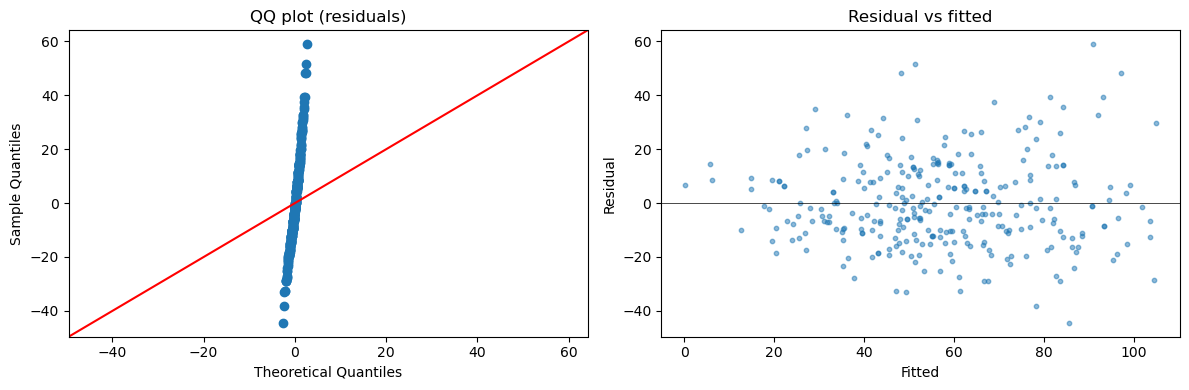

Breusch-Pagan LM stat = 27.79, p = 0.0229  (low p = heteroscedastic → HC3 justified)


In [42]:
sample_date = betas.index[len(betas) // 2]
model, cols = results[sample_date]
print(f'Sample date: {sample_date.date()}')
print(model.summary())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sm.qqplot(model.resid, line='45', ax=axes[0]); axes[0].set_title('QQ plot (residuals)')
axes[1].scatter(model.fittedvalues, model.resid, s=10, alpha=0.5)
axes[1].axhline(0, color='k', lw=0.5); axes[1].set_xlabel('Fitted'); axes[1].set_ylabel('Residual')
axes[1].set_title('Residual vs fitted')
plt.tight_layout(); plt.show()

bp = het_breuschpagan(model.resid, model.model.exog)
print(f'Breusch-Pagan LM stat = {bp[0]:.2f}, p = {bp[1]:.4f}  (low p = heteroscedastic → HC3 justified)')

In [43]:
# VIFs (on the sample day)
X_sample = model.model.exog
vif = pd.Series({cols[i]: variance_inflation_factor(X_sample, i) for i in range(len(cols))})
vif.sort_values(ascending=False)

const                         45.868432
duration                      13.348296
dur2                          13.266477
sec_Financials                 9.158097
sec_Industrials                4.261835
sec_Consumer Discretionary     3.894389
sec_Energy                     2.680516
sec_Utilities                  2.605723
sec_Government                 1.868255
sec_Materials                  1.751732
sec_Consumer Staples           1.686078
sec_Health Care                1.464971
sec_Technology                 1.457338
rat_BBB                        1.286849
rat_AAA                        1.159874
rat_AA                         1.140065
dtype: float64

## 6. Beta time-series plots

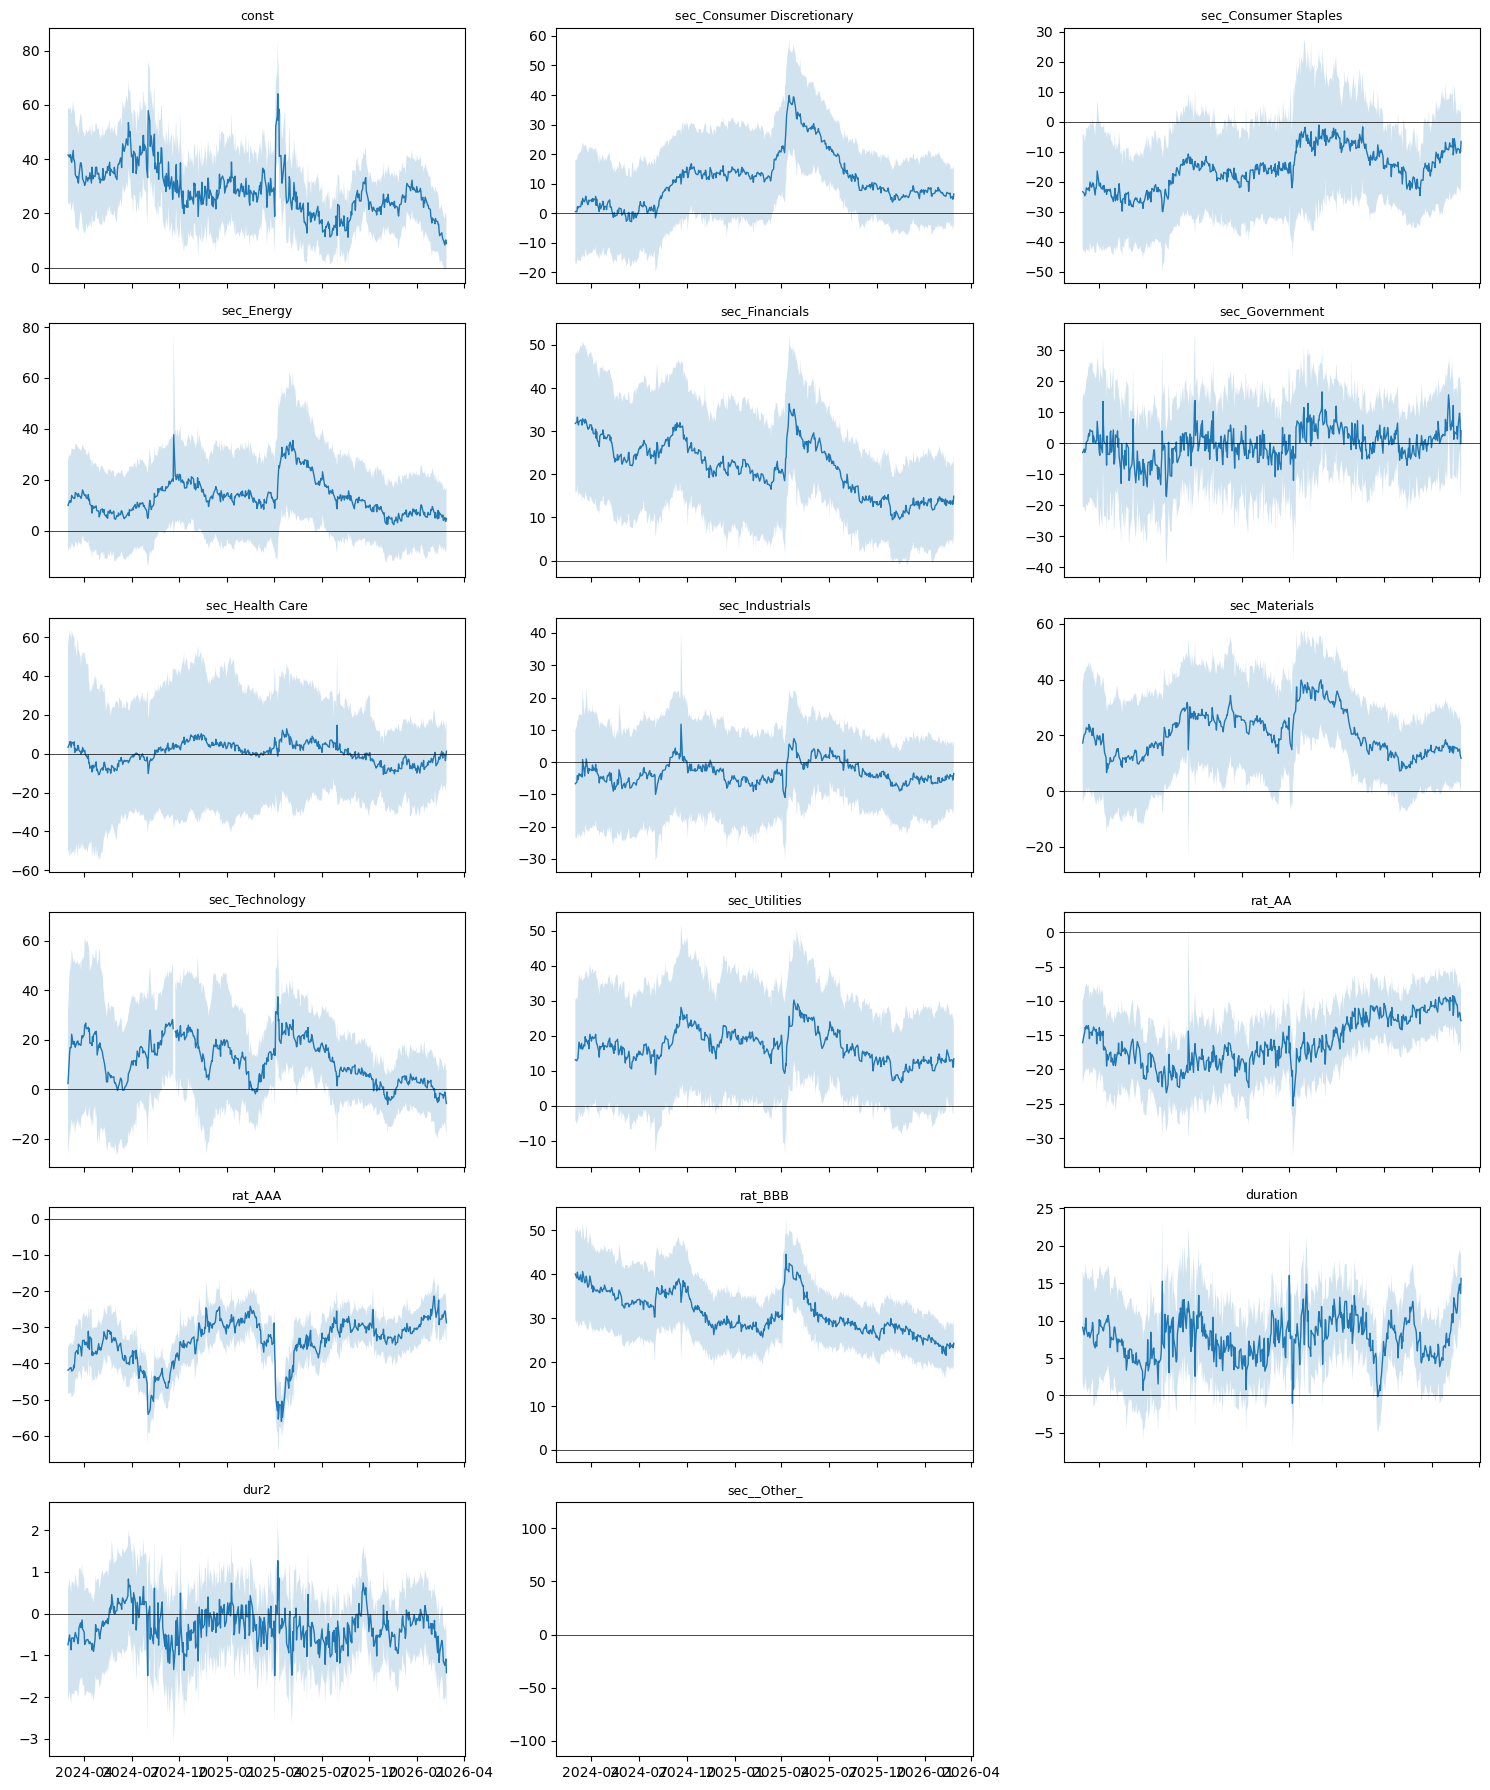

In [44]:
coef_cols = [c for c in betas.columns if c.startswith('coef_')]
factor_names = [c.replace('coef_', '') for c in coef_cols]

n = len(factor_names)
ncols = 3; nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows), sharex=True)
axes = np.atleast_2d(axes).ravel()
for ax, f in zip(axes, factor_names):
    b = betas[f'coef_{f}']; se = betas[f'se_{f}']
    ax.plot(b.index, b.values, lw=1)
    ax.fill_between(b.index, b - 1.96 * se, b + 1.96 * se, alpha=0.2)
    ax.axhline(0, color='k', lw=0.5)
    ax.set_title(f, fontsize=9)
for ax in axes[n:]:
    ax.axis('off')
plt.tight_layout(); plt.show()

In [45]:
# Fama-MacBeth style summary: average beta with Newey-West SEs
from statsmodels.tsa.stattools import adfuller

rows = []
for f in factor_names:
    b = betas[f'coef_{f}'].dropna()
    mu = b.mean()
    nw = sm.OLS(b.values, np.ones(len(b))).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    adf_p = adfuller(b.values, autolag='AIC')[1] if len(b) > 20 else np.nan
    rows.append({'factor': f, 'mean_beta': mu, 'nw_se': nw.bse[0], 't_nw': mu / nw.bse[0], 'adf_p': adf_p})
fm = pd.DataFrame(rows).set_index('factor')
fm

,mean_beta,nw_se,t_nw,adf_p
factor,,,,
const,28.628051,0.927141,30.877769,0.301201
sec_Consumer Discretionary,11.196907,0.950042,11.785696,0.528899
sec_Consumer Staples,-15.608837,0.701279,-22.257657,0.242504
sec_Energy,13.122361,0.718313,18.268299,0.417284
sec_Financials,21.791733,0.688110,31.668969,0.364590
sec_Government,-0.141874,0.463673,-0.305978,0.034196
sec_Health Care,0.217910,0.549985,0.396211,0.127291
sec_Industrials,-3.257075,0.344797,-9.446370,0.121075
sec_Materials,20.832082,0.830495,25.083924,0.362572


## 7. Residuals → mean-reversion screen

In [46]:
# Standardize residuals cross-sectionally each day
z = residuals.sub(residuals.mean(axis=1), axis=0).div(residuals.std(axis=1), axis=0)

def ar1_halflife(series, min_obs=60):
    s = series.dropna()
    if len(s) < min_obs:
        return pd.Series({'rho': np.nan, 'p': np.nan, 'half_life': np.nan, 'n': len(s)})
    y = s.values[1:]; x = sm.add_constant(s.values[:-1])
    fit = sm.OLS(y, x).fit()
    rho = fit.params[1]; p = fit.pvalues[1]
    hl = -np.log(2) / np.log(rho) if 0 < rho < 1 else np.nan
    return pd.Series({'rho': rho, 'p': p, 'half_life': hl, 'n': len(s)})

ar1 = z.apply(ar1_halflife, axis=0).T
mr = ar1[(ar1['rho'] < 1) & (ar1['p'] < 0.05)].sort_values('half_life')
print('Bonds with significant mean-reversion:', len(mr))
mr.head(20)

Bonds with significant mean-reversion: 303


,rho,p,half_life,n
cusip,,,,
YS4456861,0.236558,6.426789e-05,0.480830,280.0
02665WFE6,0.353506,8.415709e-16,0.666580,491.0
ZM1977697,0.369372,1.690408e-17,0.695966,499.0
96122XAQ1,0.371836,9.332592e-18,0.700642,499.0
24422EUB3,0.395840,3.653910e-20,0.747936,498.0
AQ1070327,0.410253,1.333621e-21,0.777958,499.0
24422EXN4,0.435201,2.792941e-24,0.833163,495.0
14913UAE0,0.449893,5.497154e-26,0.867794,498.0
65535HAQ2,0.460707,3.388973e-27,0.894392,499.0


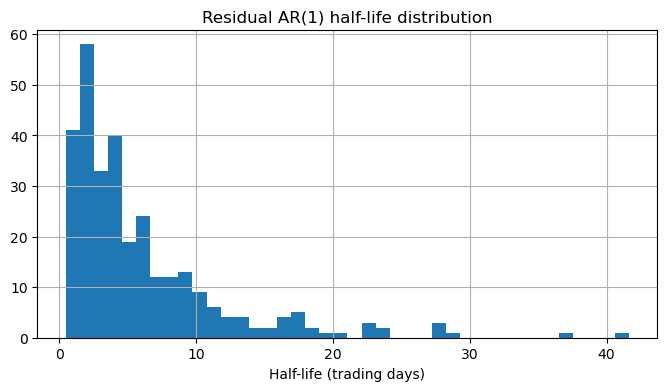

In [47]:
fig, ax = plt.subplots(figsize=(8, 4))
ar1['half_life'].dropna().clip(upper=250).hist(bins=40, ax=ax)
ax.set_xlabel('Half-life (trading days)'); ax.set_title('Residual AR(1) half-life distribution')
plt.show()

## 8. Persist outputs

In [48]:
betas.to_parquet(OUT_DIR / 'daily_betas.parquet')
residuals.to_parquet(OUT_DIR / 'residuals_panel.parquet')
ar1.to_parquet(OUT_DIR / 'residual_ar1.parquet')
print('Saved daily_betas.parquet, residuals_panel.parquet, residual_ar1.parquet')

Saved daily_betas.parquet, residuals_panel.parquet, residual_ar1.parquet
